In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
train = pd.read_csv("KDDTrain+.txt", header=None)
test = pd.read_csv("KDDTest+.txt", header=None)

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (125973, 43)
Test Shape: (22544, 43)


In [ ]:
train.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [ ]:
train.tail()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.0,1.00,1.0,0.00,0.0,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.0,0.00,0.0,0.00,0.0,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.0,0.72,0.0,0.01,0.0,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.0,1.00,1.0,0.00,0.0,neptune,20
125972,0,tcp,ftp_data,SF,151,0,0,0,0,0,...,0.30,0.03,0.30,0.0,0.00,0.0,0.00,0.0,normal,21


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   0       125973 non-null  int64  
 1   1       125973 non-null  object 
 2   2       125973 non-null  object 
 3   3       125973 non-null  object 
 4   4       125973 non-null  int64  
 5   5       125973 non-null  int64  
 6   6       125973 non-null  int64  
 7   7       125973 non-null  int64  
 8   8       125973 non-null  int64  
 9   9       125973 non-null  int64  
 10  10      125973 non-null  int64  
 11  11      125973 non-null  int64  
 12  12      125973 non-null  int64  
 13  13      125973 non-null  int64  
 14  14      125973 non-null  int64  
 15  15      125973 non-null  int64  
 16  16      125973 non-null  int64  
 17  17      125973 non-null  int64  
 18  18      125973 non-null  int64  
 19  19      125973 non-null  int64  
 20  20      125973 non-null  int64  
 21  21      12

In [ ]:
train.describe()

,0,4,5,6,7,8,9,10,11,12,...,32,33,34,35,36,37,38,39,40,42
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [ ]:
train.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [ ]:
train.duplicated().sum()

np.int64(0)

In [ ]:
columns = [
'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
'wrong_fragment','urgent','hot','num_failed_logins','logged_in',
'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
'num_shells','num_access_files','num_outbound_cmds','is_host_login',
'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
'dst_host_same_srv_rate','dst_host_diff_srv_rate',
'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
'dst_host_serror_rate','dst_host_srv_serror_rate',
'dst_host_rerror_rate','dst_host_srv_rerror_rate',
'label','difficulty'
]

train.columns = columns
test.columns = columns

In [ ]:
train.drop("difficulty", axis=1, inplace=True)
test.drop("difficulty", axis=1, inplace=True)

In [ ]:
train['label'].value_counts()

,count
label,
normal,67343
neptune,41214
satan,3633
ipsweep,3599
portsweep,2931
smurf,2646
nmap,1493
back,956
teardrop,892


In [ ]:
dos = ['back','land','neptune','pod','smurf','teardrop']
probe = ['satan','ipsweep','nmap','portsweep']
r2l = ['guess_passwd','ftp_write','imap','phf','multihop',
       'warezmaster','warezclient','spy','xlock','xsnoop','snmpguess']
u2r = ['buffer_overflow','loadmodule','perl','rootkit']

def attack_map(x):
    if x == 'normal':
        return 'normal'
    elif x in dos:
        return 'dos'
    elif x in probe:
        return 'probe'
    elif x in r2l:
        return 'r2l'
    elif x in u2r:
        return 'u2r'
    else:
        return 'other'

In [ ]:
train['label'] = train['label'].apply(attack_map)
test['label'] = test['label'].apply(attack_map)

In [ ]:
train['label'].value_counts()

,count
label,
normal,67343
dos,45927
probe,11656
r2l,995
u2r,52


In [ ]:
(train['label'].value_counts(normalize=True)) * 100

,proportion
label,
normal,53.458281
dos,36.457812
probe,9.252776
r2l,0.789852
u2r,0.041279


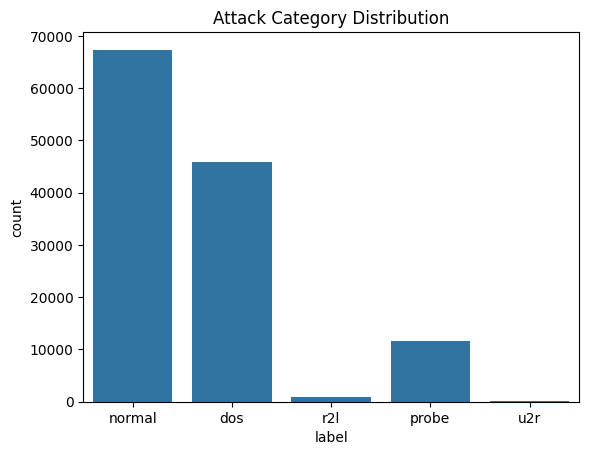

In [ ]:
sns.countplot(x=train['label'])
plt.title("Attack Category Distribution")
plt.show()

In [ ]:
train[['protocol_type','service','flag']].head()

,protocol_type,service,flag
0,tcp,ftp_data,SF
1,udp,other,SF
2,tcp,private,S0
3,tcp,http,SF
4,tcp,http,SF


In [ ]:
train = pd.get_dummies(train, columns=['protocol_type','service','flag'])
test = pd.get_dummies(test, columns=['protocol_type','service','flag'])

test = test.reindex(columns=train.columns, fill_value=0)

In [ ]:
print(train.shape)
print(test.shape)

(125973, 123)
(22544, 123)


In [ ]:
X_train = train.drop('label', axis=1)
y_train = train['label']

X_test = test.drop('label', axis=1)
y_test = test['label']

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", np.unique(y_train, return_counts=True))

After SMOTE: (array(['dos', 'normal', 'probe', 'r2l', 'u2r'], dtype=object), array([67343, 67343, 67343, 67343, 67343]))


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_rf = {
    'n_estimators': [25,50,75,100,150],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                       param_rf,
                       cv=3,
                       scoring='accuracy')

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
print("Best RF:", grid_rf.best_params_)

Best RF: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 150}


In [ ]:
from sklearn.svm import SVC

param_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(SVC(),
                        param_svm,
                        cv=3,
                        scoring='accuracy')

grid_svm.fit(X_train, y_train)

best_svm = grid_svm.best_estimator_
print("Best SVM:", grid_svm.best_params_)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

param_knn = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(KNeighborsClassifier(),
                        param_knn,
                        cv=3,
                        scoring='accuracy')

grid_knn.fit(X_train, y_train)

best_knn = grid_knn.best_estimator_
print("Best KNN:", grid_knn.best_params_)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

results = []

def evaluate_model(model, name):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print("\n", name)
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(name)
    plt.show()

    from sklearn.metrics import precision_score, recall_score, f1_score

    results.append([
        name,
        acc,
        precision_score(y_test, y_pred, average='macro', zero_division=0),
        recall_score(y_test, y_pred, average='macro'),
        f1_score(y_test, y_pred, average='macro')
    ])

In [ ]:
evaluate_model(best_rf, "Random Forest Tuned")
evaluate_model(best_svm, "SVM Tuned")
evaluate_model(best_knn, "KNN Tuned")